# 04 · The whole curve → an image → a CNN

A single hardness number throws away the *shape* of the indentation response.
Following the Small-Methods approach, we turn each **load–depth curve into an
image** with a **Gramian Angular Field (GAF)** and let a small **CNN** read it,
then compare it against a lighter **PCA → Random Forest** "feature route".

You will learn:
1. how a 1-D curve becomes a 2-D **GAF image**,
2. a compact **CNN** in PyTorch (CPU, seconds to train),
3. a crucial practical lesson: **the GAF encodes *shape* and is scale-invariant**,
   so you must match the representation to what actually separates your classes.

> Public/own data only. Task: hard vs soft phase on the AFM grid (labels from
> hardness, used only as ground truth).

In [1]:
# --- setup: find the repo (auto-clone on Colab), load helpers, set plot style ---
import os, sys, subprocess
def _find_src():
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None
if _find_src() is None:                    # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)
sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import mecanano_ml as mm
mm.set_style()
print("helpers loaded from:", mm.__file__)

helpers loaded from: /tmp/stage/repo/src/mecanano_ml/__init__.py


In [2]:
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix
torch.manual_seed(0); np.random.seed(0)

## 1 · Curves and labels
Each indent's **load–depth curve** is the input; the label is simply hard vs soft phase (split at median hardness).

In [3]:
afm = mm.load_afm_grid()
Craw = afm["load_mN"].copy()                 # (n, 64) load vs depth
keep = np.isfinite(Craw).mean(0) > 0.5
Craw = SimpleImputer(strategy="median").fit_transform(Craw[:, keep])
ok = Craw.std(1) > 1e-6                       # drop flat/dead curves
Craw = Craw[ok]
y = (afm["H"][ok] > np.median(afm["H"][ok])).astype(int)
print("curves:", Craw.shape, " hard/soft:", int(y.sum()), int((1-y).sum()))

curves: (828, 64)  hard/soft: 414 414


## 2 · Curve → GAF image
The GAF encodes the curve's values and their temporal correlations as a square image the CNN can convolve over.

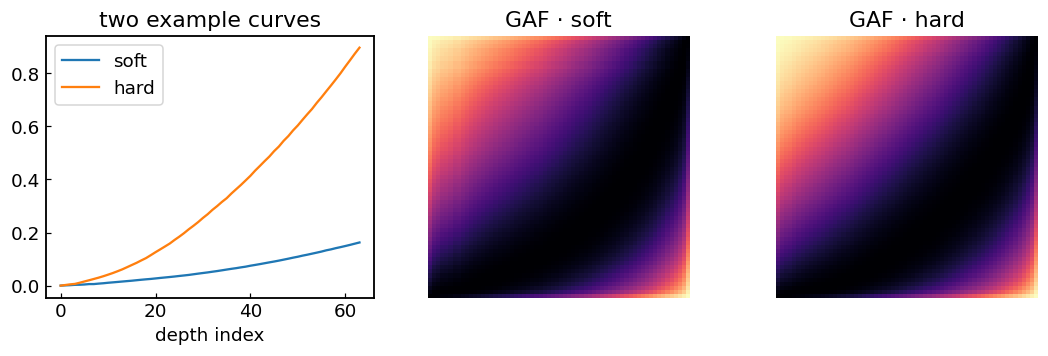

In [4]:
from pyts.image import GramianAngularField
gaf = GramianAngularField(image_size=Craw.shape[1], method="summation")
imgs = gaf.fit_transform(Craw)               # (n, L, L) in [-1, 1]
fig, ax = plt.subplots(1,3, figsize=(10,3.4))
ax[0].plot(Craw[np.where(y==0)[0][0]], label="soft"); ax[0].plot(Craw[np.where(y==1)[0][0]], label="hard")
ax[0].legend(); ax[0].set_title("two example curves"); ax[0].set_xlabel("depth index")
ax[1].imshow(imgs[np.where(y==0)[0][0]], cmap="magma"); ax[1].set_title("GAF · soft"); ax[1].axis("off")
ax[2].imshow(imgs[np.where(y==1)[0][0]], cmap="magma"); ax[2].set_title("GAF · hard"); ax[2].axis("off")
fig.tight_layout()

**Key property — the GAF is scale-invariant.** It rescales every curve to [-1, 1] first, so a curve and the *same curve shifted and doubled* give an **identical** image. The GAF sees **shape**, not magnitude — keep this in mind.

In [5]:
g1 = gaf.transform(Craw[:1]); g2 = gaf.transform(2*Craw[:1] + 3)
print("max |GAF(x) - GAF(2x+3)| =", round(float(np.abs(g1-g2).max()), 6), " -> the same image")

max |GAF(x) - GAF(2x+3)| = 1e-06  -> the same image


## 3 · A small CNN
Two convolution blocks and a linear head — a few thousand parameters, trained on the CPU in seconds.

In [6]:
Xtr, Xte, ytr, yte = train_test_split(imgs, y, test_size=0.3, stratify=y, random_state=0)
def loader(X, yy, bs=32, shuffle=False):
    t = TensorDataset(torch.tensor(X[:,None], dtype=torch.float32), torch.tensor(yy, dtype=torch.long))
    return DataLoader(t, batch_size=bs, shuffle=shuffle)
L = imgs.shape[1]
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.f = nn.Sequential(nn.Conv2d(1,8,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
                               nn.Conv2d(8,16,3,padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.c = nn.Sequential(nn.Flatten(), nn.Linear(16*(L//4)*(L//4), 32), nn.ReLU(), nn.Linear(32,2))
    def forward(self,x): return self.c(self.f(x))
net = SmallCNN(); opt = torch.optim.Adam(net.parameters(), 1e-3); lossf = nn.CrossEntropyLoss()
print("parameters:", sum(p.numel() for p in net.parameters()))

parameters: 132418


In [7]:
tr, te = loader(Xtr,ytr,shuffle=True), loader(Xte,yte)
for epoch in range(25):
    net.train()
    for xb,yb in tr:
        opt.zero_grad(); lossf(net(xb), yb).backward(); opt.step()
net.eval()
with torch.no_grad():
    pred = torch.cat([net(xb).argmax(1) for xb,_ in te]).numpy()
acc_cnn = accuracy_score(yte, pred)
print("CNN (image route, shape only) test accuracy:", round(acc_cnn, 3))

CNN (image route, shape only) test accuracy: 0.699


## 4 · The feature route (PCA → Random Forest)
The same curves, but kept as raw vectors so **absolute scale is preserved**. Watch the accuracy gap.

CNN (GAF, shape)      : 0.699
PCA+RF (raw, keeps scale): 0.904


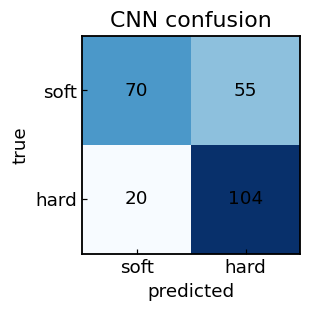

In [8]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
Ftr, Fte, gtr, gte = train_test_split(Craw, y, test_size=0.3, stratify=y, random_state=0)
feat = make_pipeline(StandardScaler(), PCA(6), RandomForestClassifier(200, random_state=0)).fit(Ftr, gtr)
acc_feat = accuracy_score(gte, feat.predict(Fte))
print(f"CNN (GAF, shape)      : {acc_cnn:.3f}")
print(f"PCA+RF (raw, keeps scale): {acc_feat:.3f}")
fig, ax = plt.subplots(figsize=(3.3,3))
cm = confusion_matrix(yte, pred); im=ax.imshow(cm, cmap="Blues")
ax.set_xticks([0,1],["soft","hard"]); ax.set_yticks([0,1],["soft","hard"])
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("CNN confusion")
for (i,j),v in np.ndenumerate(cm): ax.text(j,i,f"{v}",ha="center",va="center")
fig.tight_layout()

## Recap — match the representation to the class difference
- A **GAF** turns each curve into an image so a **CNN** can read the *whole* response.
- But the GAF is **scale-invariant**: it captures **shape**, not magnitude. Here the
  two phases differ mostly in *level*, so the **feature route that keeps scale wins**.
- The Small-Methods CNN succeeds because its curves are **self-normalised**, so the
  *shape* carries the phase — exactly the regime where the image route beats scalars.
- **Practical rule:** try both routes; use GAF/CNN when *shape* discriminates and add
  scalar features (or a 1-D CNN on the raw curve) when *magnitude* does.

**Next:** `05_autoencoder_latent_space.ipynb` — learn a latent space of curves.